In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sympy import *
from scipy import stats
from datetime import timedelta
import warnings

In [2]:
data ='D:\AI Course\Applied Machine Intelligence\Covid vaccination types.csv'

In [3]:
#read the data into the notebook
Vac = pd.read_csv(data)

In [4]:
Vac

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,22/02/2021,0.0,0.0,NaN,NaN,NaN,0.00,0.00,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,23/02/2021,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,24/02/2021,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,25/02/2021,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,26/02/2021,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86507,Zimbabwe,ZWE,25/03/2022,8691642.0,4814582.0,3473523.0,139213.0,69579.0,57.59,31.90,23.02,4610.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...
86508,Zimbabwe,ZWE,26/03/2022,8791728.0,4886242.0,3487962.0,100086.0,83429.0,58.25,32.38,23.11,5528.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...
86509,Zimbabwe,ZWE,27/03/2022,8845039.0,4918147.0,3493763.0,53311.0,90629.0,58.61,32.59,23.15,6005.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...
86510,Zimbabwe,ZWE,28/03/2022,8934360.0,4975433.0,3501493.0,89321.0,100614.0,59.20,32.97,23.20,6667.0,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac...",Ministry of Health,https://www.arcgis.com/home/webmap/viewer.html...


In [5]:
Vac['vaccines'].nunique()

84

In [6]:
Vac.drop(columns =['source_name','source_website','iso_code','daily_vaccinations_raw','daily_vaccinations_per_million'], axis=1, inplace=True)

In [8]:
Vac.dropna(inplace=True)

In [9]:
Vac

,country,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,vaccines
78,Afghanistan,11/05/2021,504502.0,448878.0,55624.0,13921.0,1.27,1.13,0.14,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
87,Afghanistan,20/05/2021,547901.0,470341.0,77560.0,4822.0,1.38,1.18,0.19,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
91,Afghanistan,24/05/2021,573277.0,476367.0,96910.0,5692.0,1.44,1.20,0.24,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
93,Afghanistan,26/05/2021,590454.0,479372.0,111082.0,6768.0,1.48,1.20,0.28,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
94,Afghanistan,27/05/2021,593313.0,479574.0,113739.0,6487.0,1.49,1.20,0.29,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
...,...,...,...,...,...,...,...,...,...,...
86507,Zimbabwe,25/03/2022,8691642.0,4814582.0,3473523.0,69579.0,57.59,31.90,23.02,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."
86508,Zimbabwe,26/03/2022,8791728.0,4886242.0,3487962.0,83429.0,58.25,32.38,23.11,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."
86509,Zimbabwe,27/03/2022,8845039.0,4918147.0,3493763.0,90629.0,58.61,32.59,23.15,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."
86510,Zimbabwe,28/03/2022,8934360.0,4975433.0,3501493.0,100614.0,59.20,32.97,23.20,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."


In [11]:
Vac[Vac['vaccines'].str.contains('Oxford/AstraZeneca')]

,country,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,vaccines
78,Afghanistan,11/05/2021,504502.0,448878.0,55624.0,13921.0,1.27,1.13,0.14,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
87,Afghanistan,20/05/2021,547901.0,470341.0,77560.0,4822.0,1.38,1.18,0.19,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
91,Afghanistan,24/05/2021,573277.0,476367.0,96910.0,5692.0,1.44,1.20,0.24,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
93,Afghanistan,26/05/2021,590454.0,479372.0,111082.0,6768.0,1.48,1.20,0.28,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
94,Afghanistan,27/05/2021,593313.0,479574.0,113739.0,6487.0,1.49,1.20,0.29,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
...,...,...,...,...,...,...,...,...,...,...
86507,Zimbabwe,25/03/2022,8691642.0,4814582.0,3473523.0,69579.0,57.59,31.90,23.02,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."
86508,Zimbabwe,26/03/2022,8791728.0,4886242.0,3487962.0,83429.0,58.25,32.38,23.11,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."
86509,Zimbabwe,27/03/2022,8845039.0,4918147.0,3493763.0,90629.0,58.61,32.59,23.15,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."
86510,Zimbabwe,28/03/2022,8934360.0,4975433.0,3501493.0,100614.0,59.20,32.97,23.20,"Oxford/AstraZeneca, Sinopharm/Beijing, Sinovac..."


In [13]:
Vac[Vac['vaccines'].str.contains('Pfizer')]

,country,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,vaccines
78,Afghanistan,11/05/2021,504502.0,448878.0,55624.0,13921.0,1.27,1.13,0.14,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
87,Afghanistan,20/05/2021,547901.0,470341.0,77560.0,4822.0,1.38,1.18,0.19,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
91,Afghanistan,24/05/2021,573277.0,476367.0,96910.0,5692.0,1.44,1.20,0.24,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
93,Afghanistan,26/05/2021,590454.0,479372.0,111082.0,6768.0,1.48,1.20,0.28,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
94,Afghanistan,27/05/2021,593313.0,479574.0,113739.0,6487.0,1.49,1.20,0.29,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi..."
...,...,...,...,...,...,...,...,...,...,...
85069,Wales,24/03/2022,6921195.0,2526832.0,2397677.0,1705.0,218.33,79.71,75.64,"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech"
85070,Wales,25/03/2022,6923298.0,2527100.0,2398097.0,1667.0,218.40,79.72,75.65,"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech"
85071,Wales,26/03/2022,6923706.0,2527184.0,2398322.0,1519.0,218.41,79.72,75.66,"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech"
85072,Wales,27/03/2022,6925183.0,2528051.0,2398676.0,1505.0,218.46,79.75,75.67,"Moderna, Oxford/AstraZeneca, Pfizer/BioNTech"


In [14]:
display(Vac[Vac["vaccines"]=="Oxford/AstraZeneca"])

,country,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,vaccines
1723,Angola,12/05/2021,626572.0,586377.0,40195.0,8959.0,1.85,1.73,0.12,Oxford/AstraZeneca
1729,Angola,18/05/2021,681502.0,606287.0,75215.0,9127.0,2.01,1.79,0.22,Oxford/AstraZeneca
1732,Angola,21/05/2021,757535.0,630984.0,126551.0,16093.0,2.23,1.86,0.37,Oxford/AstraZeneca
1737,Angola,26/05/2021,859979.0,663049.0,196930.0,21876.0,2.53,1.95,0.58,Oxford/AstraZeneca
1742,Angola,31/05/2021,909215.0,679034.0,230181.0,12888.0,2.68,2.00,0.68,Oxford/AstraZeneca
...,...,...,...,...,...,...,...,...,...,...
83777,Vanuatu,20/12/2021,152711.0,102308.0,50403.0,729.0,48.56,32.53,16.03,Oxford/AstraZeneca
83812,Vanuatu,24/01/2022,178464.0,109176.0,69288.0,736.0,56.75,34.72,22.03,Oxford/AstraZeneca
83826,Vanuatu,07/02/2022,184045.0,110235.0,73810.0,399.0,58.53,35.05,23.47,Oxford/AstraZeneca
83840,Vanuatu,21/02/2022,189138.0,110907.0,78231.0,364.0,60.15,35.27,24.88,Oxford/AstraZeneca


In [16]:
display(Vac[Vac["vaccines"]=="Pfizer/BioNTech"])

,country,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,vaccines
3664,Aruba,10/04/2021,41096.0,29197.0,11899.0,1278.0,38.34,27.24,11.10,Pfizer/BioNTech
3666,Aruba,12/04/2021,43073.0,31139.0,11934.0,1195.0,40.18,29.05,11.13,Pfizer/BioNTech
3667,Aruba,13/04/2021,45588.0,33563.0,12025.0,1372.0,42.53,31.31,11.22,Pfizer/BioNTech
3668,Aruba,14/04/2021,48200.0,36058.0,12142.0,1562.0,44.96,33.64,11.33,Pfizer/BioNTech
3669,Aruba,15/04/2021,50546.0,37981.0,12565.0,1715.0,47.15,35.43,11.72,Pfizer/BioNTech
...,...,...,...,...,...,...,...,...,...,...
80510,Turks and Caicos Islands,11/02/2022,67463.0,30801.0,28811.0,0.0,171.99,78.52,73.45,Pfizer/BioNTech
80517,Turks and Caicos Islands,18/02/2022,67965.0,31082.0,29032.0,72.0,173.27,79.24,74.01,Pfizer/BioNTech
80524,Turks and Caicos Islands,25/02/2022,68176.0,31165.0,29160.0,30.0,173.80,79.45,74.34,Pfizer/BioNTech
80538,Turks and Caicos Islands,11/03/2022,68464.0,31296.0,29317.0,21.0,174.54,79.78,74.74,Pfizer/BioNTech


In [17]:
display(Vac[Vac["vaccines"]=="Moderna"])

,country,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,vaccines
30726,Greenland,01/03/2021,5130.0,3927.0,1203.0,77.0,9.02,6.91,2.12,Moderna
30765,Greenland,09/04/2021,9555.0,5296.0,4259.0,113.0,16.80,9.31,7.49,Moderna
30768,Greenland,12/04/2021,9808.0,5531.0,4277.0,101.0,17.25,9.73,7.52,Moderna
30769,Greenland,13/04/2021,9996.0,5700.0,4296.0,112.0,17.58,10.02,7.55,Moderna
30770,Greenland,14/04/2021,10142.0,5845.0,4297.0,116.0,17.83,10.28,7.56,Moderna
...,...,...,...,...,...,...,...,...,...,...
85326,Wallis and Futuna,30/11/2021,11939.0,6016.0,5923.0,4.0,107.62,54.23,53.39,Moderna
85368,Wallis and Futuna,11/01/2022,12247.0,6130.0,6117.0,7.0,110.39,55.26,55.14,Moderna
85375,Wallis and Futuna,18/01/2022,12287.0,6151.0,6136.0,6.0,110.75,55.44,55.31,Moderna
85416,Wallis and Futuna,28/02/2022,12849.0,6450.0,6399.0,14.0,115.82,58.14,57.68,Moderna


In [20]:
Moderna_vac = Vac[Vac["vaccines"]=="Moderna"].people_fully_vaccinated_per_hundred
Pfizer_vac = Vac[Vac["vaccines"]=="Pfizer/BioNTech"].people_fully_vaccinated_per_hundred
Oxford_vac = Vac[Vac["vaccines"]=="Oxford/AstraZeneca"].people_fully_vaccinated_per_hundred

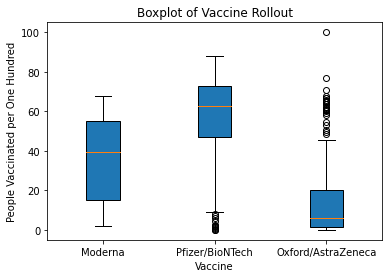

In [24]:
box_plot_data=[Moderna_vac,Pfizer_vac,Oxford_vac]
plt.boxplot(box_plot_data,patch_artist=True,labels=['Moderna','Pfizer/BioNTech','Oxford/AstraZeneca'])

plt.xlabel('Vaccine')
plt.ylabel('People Vaccinated per One Hundred')
plt.title('Boxplot of Vaccine Rollout')
plt.show()